# **Cluster Analysis**



## IMPORTING LIBRARIES

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as mngn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [8]:
data=pd.read_excel('World_development_mesurement (1).xlsx')
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


## EDA (Exploratory Data Analysis)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [11]:
data.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


### MISSING VALUES

In [13]:
data.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [14]:
data.isnull().sum().sum()

11740

In [15]:
missing_values_percentage=data.isnull().sum()*100/len(data)
missing_values_percentage

Birth Rate                 4.400888
Business Tax Rate         47.374260
CO2 Emissions             21.412722
Country                    0.000000
Days to Start Business    36.464497
Ease of Business          93.158284
Energy Usage              33.986686
GDP                        7.766272
Health Exp % GDP          11.427515
Health Exp/Capita         11.427515
Hours to do Tax           47.633136
Infant Mortality Rate      9.615385
Internet Usage             6.397929
Lending Interest          30.473373
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Mobile Phone Usage         6.176036
Number of Records          0.000000
Population 0-14            8.136095
Population 15-64           8.136095
Population 65+             8.136095
Population Total           0.000000
Population Urban           0.961538
Tourism Inbound           13.609467
Tourism Outbound          17.418639
dtype: float64

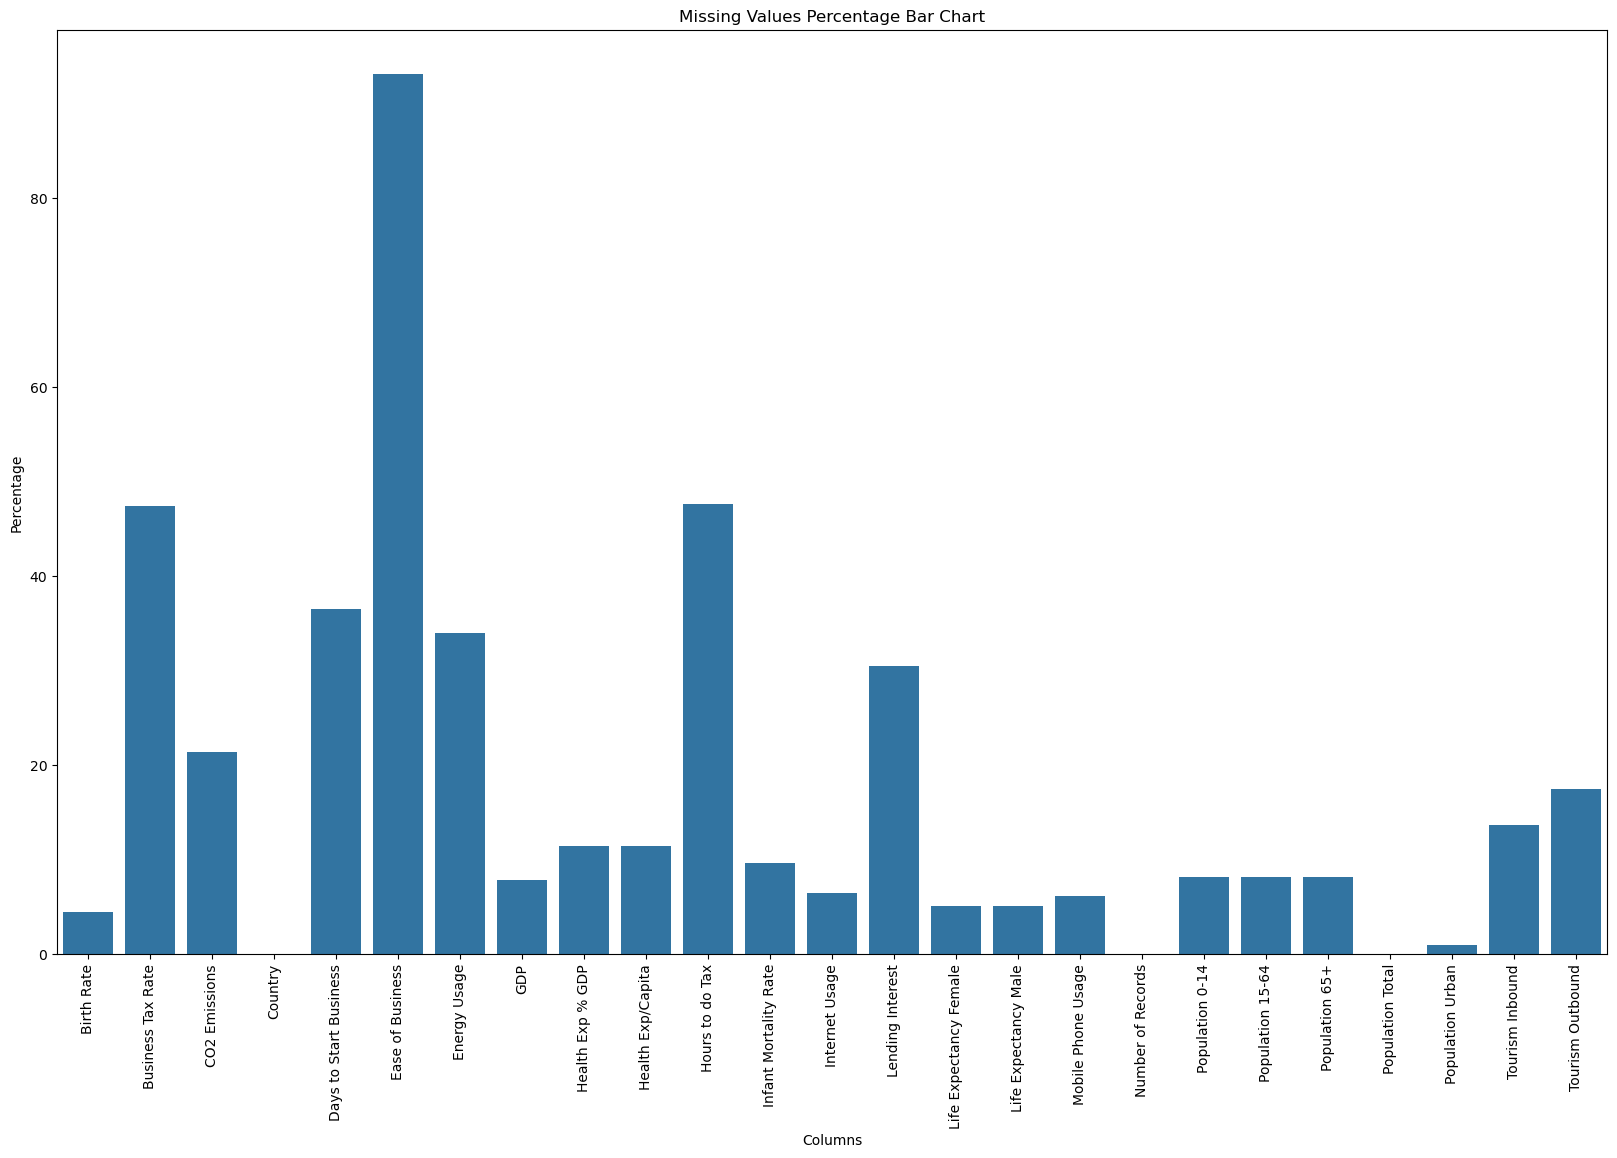

In [16]:
plt.figure(figsize=(20,12))
sns.barplot(x=missing_values_percentage.index,y=missing_values_percentage.values)
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Missing Values Percentage Bar Chart')
plt.show()

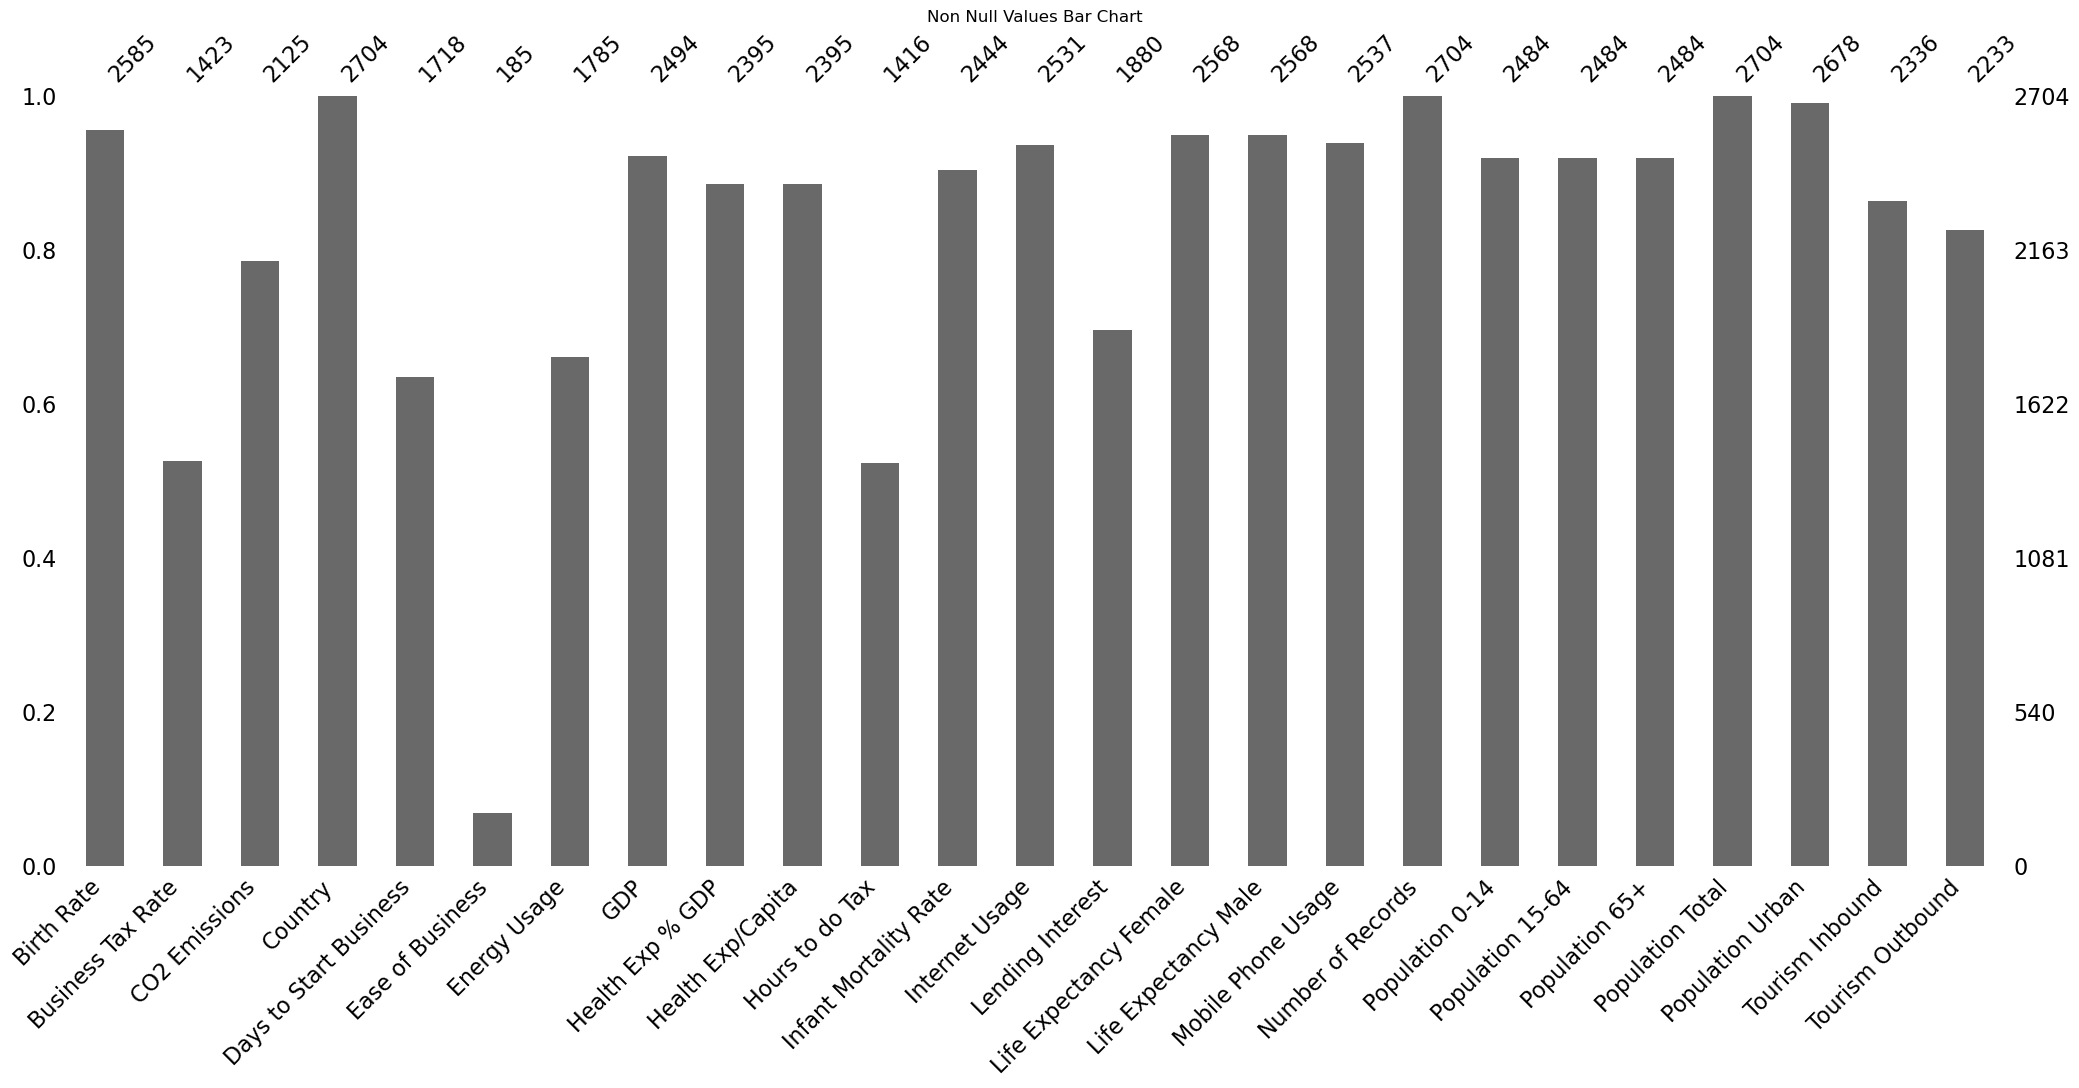

In [17]:
mngn.bar(data)
plt.title('Non Null Values Bar Chart')
plt.show()

### Removing Symbols

In [27]:
# Remove '%' from "Business Tax Rate" and convert to numeric
data["Business Tax Rate"] = data["Business Tax Rate"].astype(str).str.replace('%', '', regex=True)
data["Business Tax Rate"] = pd.to_numeric(data["Business Tax Rate"], errors='coerce')

# Remove '$' and ',' from "GDP" and convert to numeric
data['GDP']=data['GDP'].astype(str).str.replace('[$,]','',regex=True)
data['GDP']=pd.to_numeric(data['GDP'],errors='coerce')

# Remove '$' and ',' from "Health Exp/Capita" and convert to numeric
data['Health Exp/Capita']=data['Health Exp/Capita'].astype(str).str.replace('[$,]','',regex =True )
data['Health Exp/Capita']=pd.to_numeric(data['Health Exp/Capita'],errors='coerce')

# Remove '$' and ',' from "Tourism Inbound" and convert to numeric
data['Tourism Inbound']=data['Tourism Inbound'].astype(str).str.replace('[$,]','',regex =True )
data['Tourism Inbound']=pd.to_numeric(data['Tourism Inbound'],errors='coerce')

# Remove '$' and ',' from "Tourism Outbound" and convert to numeric
data['Tourism Outbound']=data['Tourism Outbound'].astype(str).str.replace('[$,]','',regex =True )
data['Tourism Outbound']=pd.to_numeric(data['Tourism Outbound'],errors='coerce')

In [28]:
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,5.479006e+10,0.035,60.0,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,1.020000e+08,1.930000e+08
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,9.129595e+09,0.034,22.0,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,3.400000e+07,1.460000e+08
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,2.359122e+09,0.043,15.0,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,7.700000e+07,5.000000e+07
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,5.788312e+09,0.047,152.0,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,2.270000e+08,2.090000e+08
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,2.610959e+09,0.051,12.0,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,2.300000e+07,3.000000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4,NaN,United States,5.0,4.0,2132446.0,1.624460e+13,0.179,8895.0,...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,2.000920e+11,1.265730e+11
2701,0.015,41.9,NaN,Uruguay,7.0,85.0,NaN,5.000435e+10,0.089,1308.0,...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,2.222000e+09,1.028000e+09
2702,0.020,61.9,NaN,"Venezuela, RB",144.0,180.0,NaN,3.812862e+11,0.046,593.0,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,9.040000e+08,3.202000e+09


### Dropping Columns

In [33]:
threshold=50
noneed=missing_values_percentage[missing_values_percentage>threshold].index
noneed

Index(['Ease of Business'], dtype='object')

In [35]:
data['Number of Records'].unique()

array([1], dtype=int64)

In [37]:
data.drop(columns=['Ease of Business','Number of Records'],inplace=True)
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,26998.0,5.479006e+10,0.035,60.0,NaN,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449,0.599,1.020000e+08,1.930000e+08
1,0.050,NaN,9542.0,Angola,NaN,7499.0,9.129595e+09,0.034,22.0,NaN,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930,0.324,3.400000e+07,1.460000e+08
2,0.043,NaN,1617.0,Benin,NaN,1983.0,2.359122e+09,0.043,15.0,NaN,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366,0.383,7.700000e+07,5.000000e+07
3,0.027,NaN,4276.0,Botswana,NaN,1836.0,5.788312e+09,0.047,152.0,NaN,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375,0.532,2.270000e+08,2.090000e+08
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,2.610959e+09,0.051,12.0,NaN,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944,0.178,2.300000e+07,3.000000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4,NaN,United States,5.0,2132446.0,1.624460e+13,0.179,8895.0,175.0,...,81.0,76.0,1.0,0.196,0.667,0.136,313873685,0.811,2.000920e+11,1.265730e+11
2701,0.015,41.9,NaN,Uruguay,7.0,NaN,5.000435e+10,0.089,1308.0,310.0,...,80.0,74.0,1.5,0.220,0.639,0.140,3395253,0.948,2.222000e+09,1.028000e+09
2702,0.020,61.9,NaN,"Venezuela, RB",144.0,NaN,3.812862e+11,0.046,593.0,792.0,...,78.0,72.0,1.0,0.288,0.652,0.060,29954782,0.889,9.040000e+08,3.202000e+09


### Filling Nulls

In [40]:
numerical_data=data.select_dtypes(include=['int64','float64']).columns
numerical_data

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [42]:
categorical_data=data.select_dtypes(include=['object']).columns
categorical_data

Index(['Country'], dtype='object')

In [44]:
for i in numerical_data:
  data[i]=data[i].fillna(data[i].mean())

In [46]:
data.isnull().sum().sum()

0

### Visualization

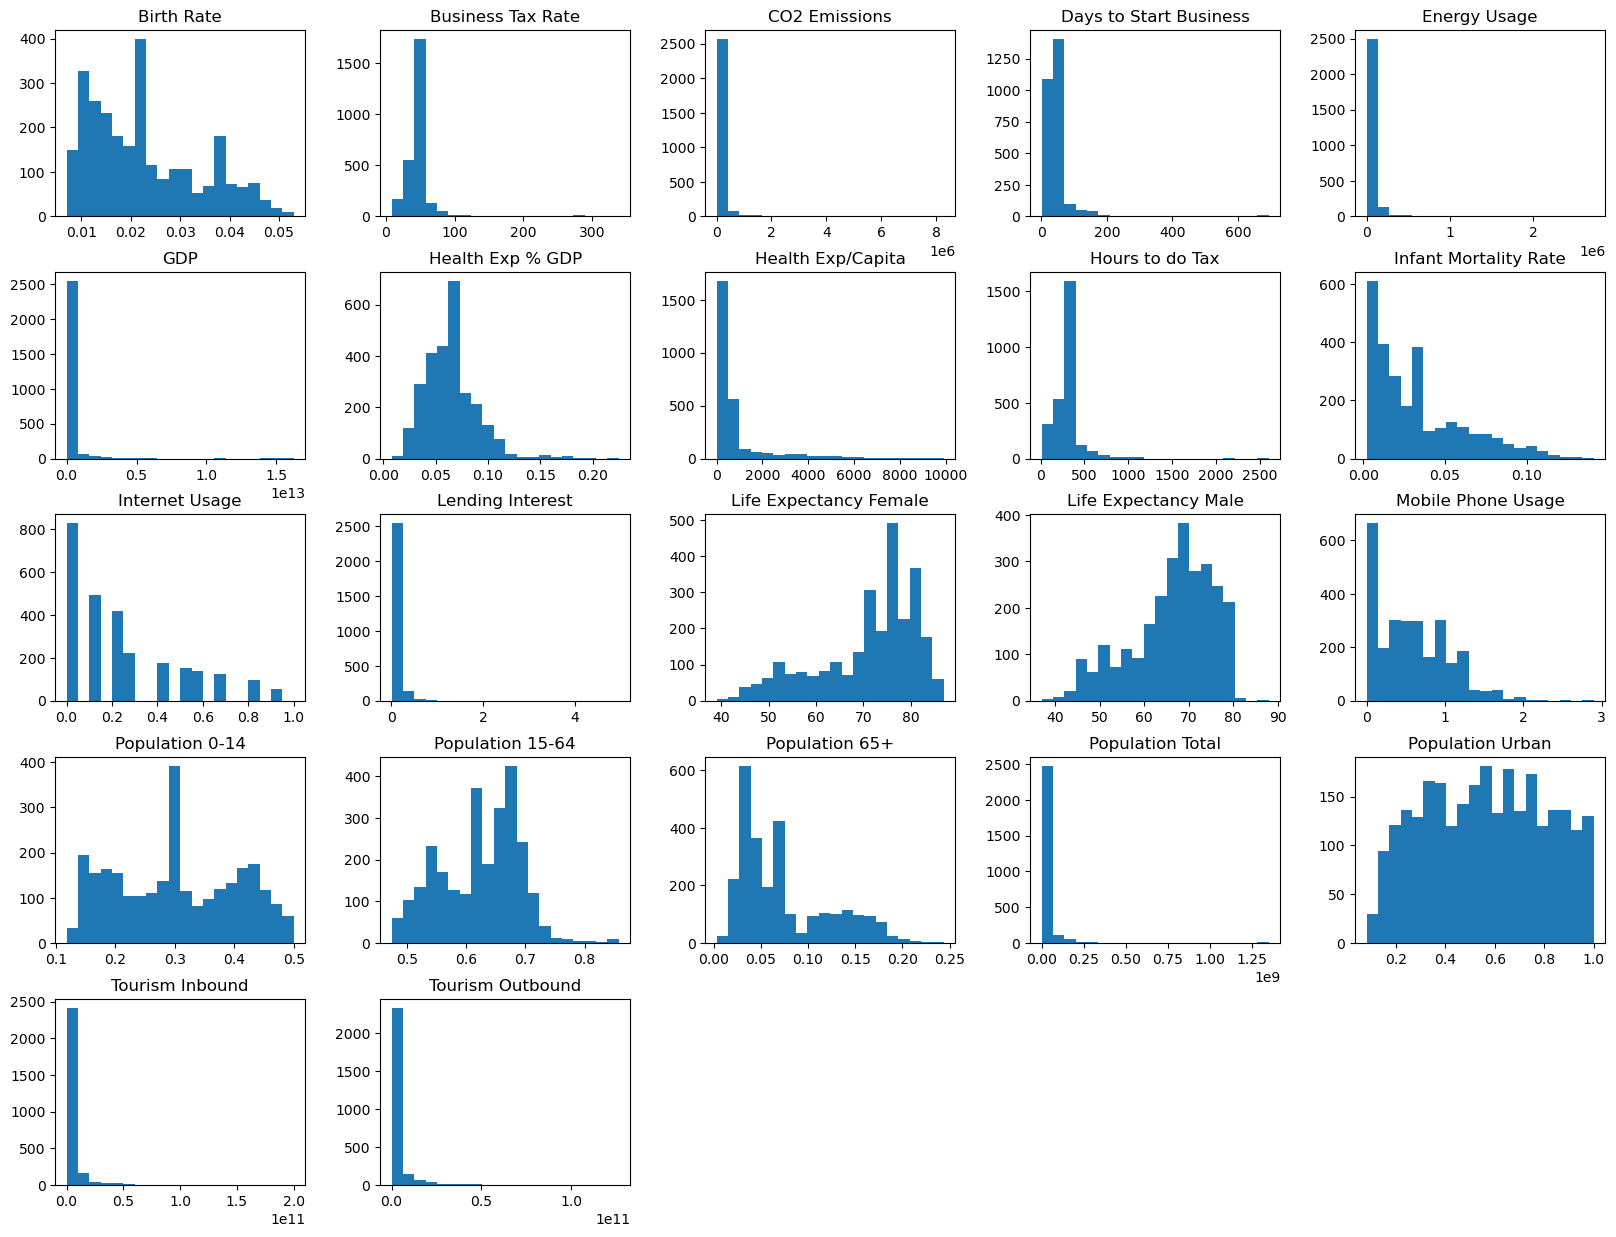

In [49]:
data.hist(bins=20,figsize=(20,15),grid=False)
plt.title('HISTOGRAM')
plt.show()

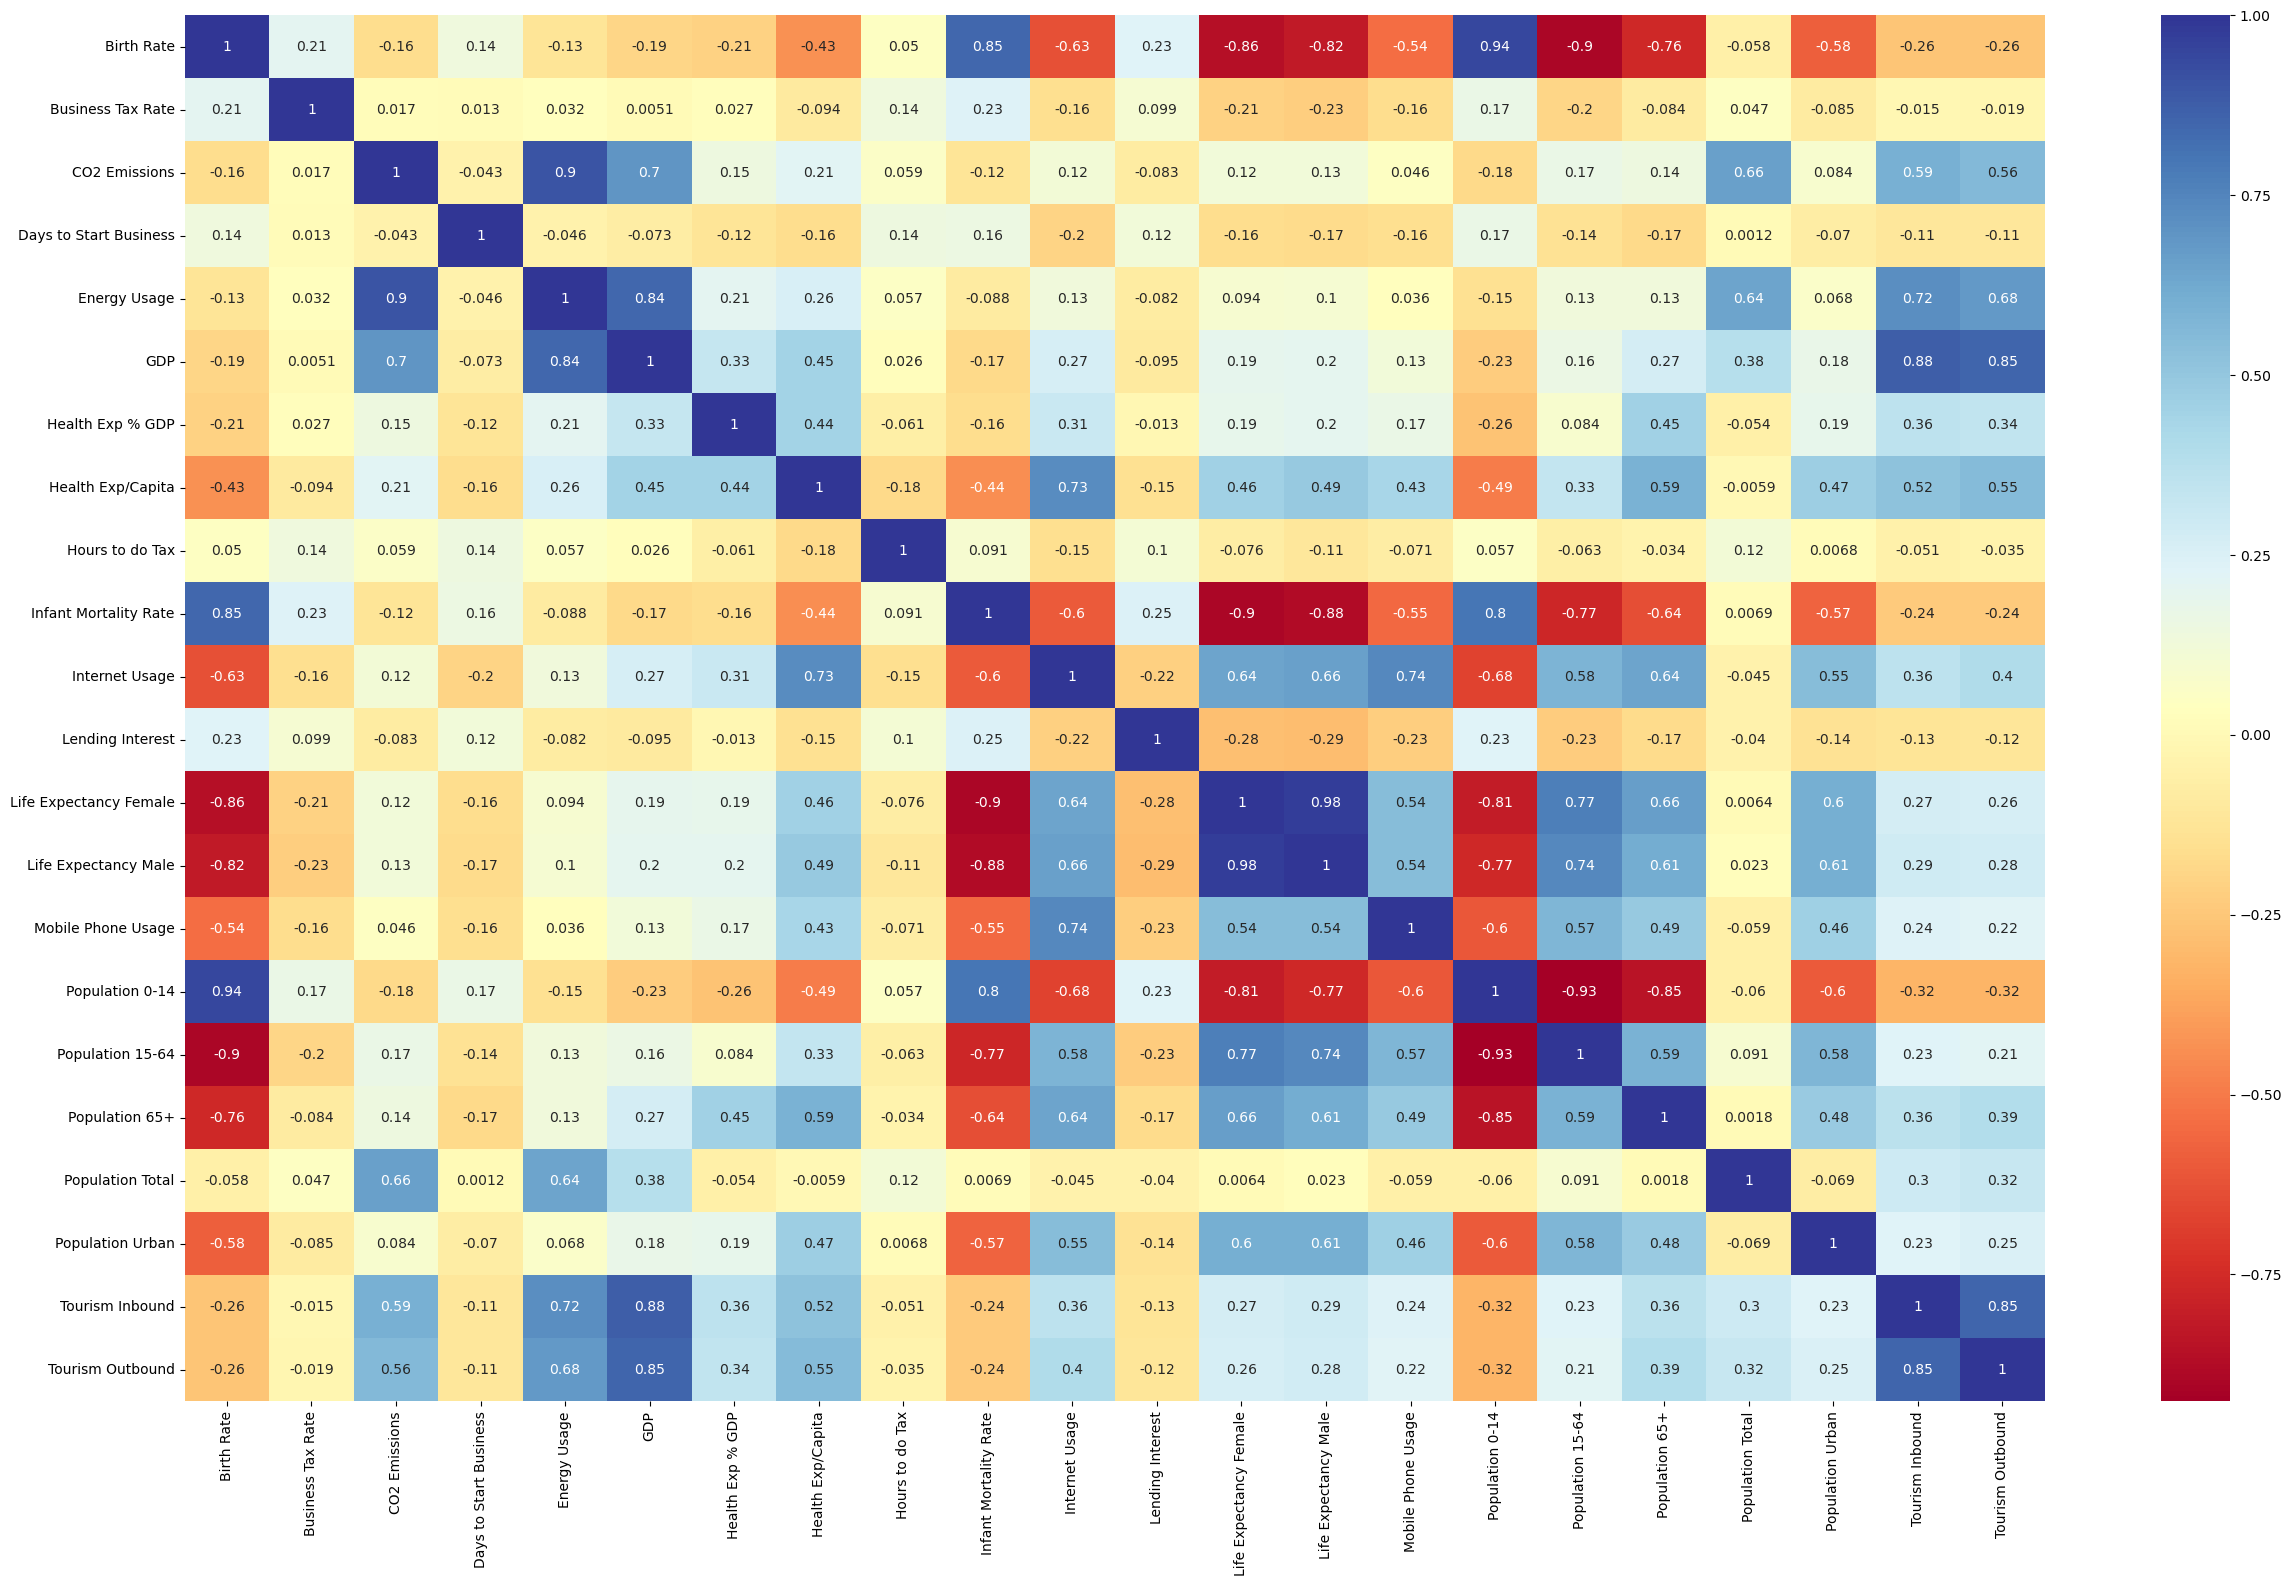

In [50]:
plt.figure(figsize=(30,18))
correlation=data.select_dtypes(include=('int','float64')).corr()
sns.heatmap(correlation,cmap="RdYlBu",annot=True)
plt.show()

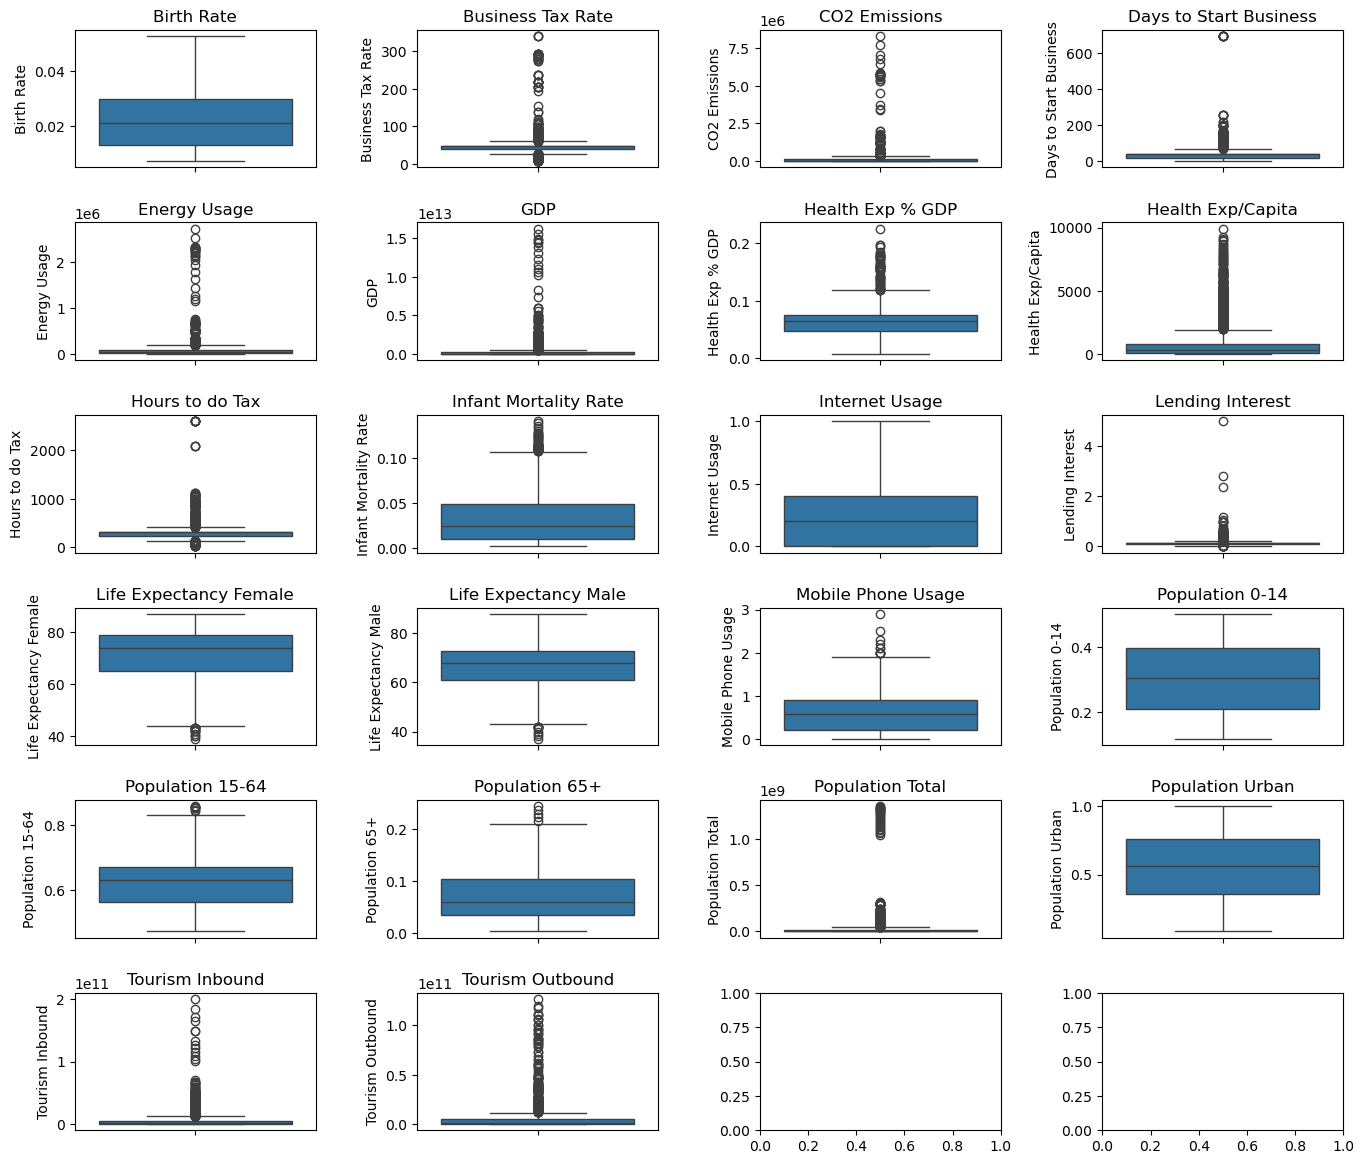

In [51]:
fig, axes = plt.subplots(6, 4, figsize=(14, 12), sharex=False, sharey=False)
axes = axes.flatten()

for i, col in enumerate(numerical_data):
    sns.boxplot(data[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.0)
plt.show()

## Implementing Clustering Algorithms

### K-Means Clustering

In [57]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data.drop(columns=['Country']))
scaled_data

array([[-2.44938515e-01,  0.00000000e+00, -9.96101719e-02, ...,
         1.47332941e-01, -3.75823649e-01, -3.76334486e-01],
       [ 2.46167047e+00,  0.00000000e+00, -2.43208934e-01, ...,
        -9.76646386e-01, -3.81106741e-01, -3.80233522e-01],
       [ 1.83012837e+00,  0.00000000e+00, -2.57726535e-01, ...,
        -7.35501730e-01, -3.77765962e-01, -3.88197509e-01],
       ...,
       [-6.96040012e-01, -2.37949604e-01,  0.00000000e+00, ...,
         1.57376489e+00, -2.11115485e-01, -3.07064385e-01],
       [-2.44938515e-01,  4.35470349e-01,  0.00000000e+00, ...,
         1.33262023e+00, -3.13514240e-01, -1.26713248e-01],
       [-1.05692121e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.57785208e+00,  0.00000000e+00, -7.91151091e-17]])

In [59]:
wcss=[]
for i in  range(1,15):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
wcss

[59487.99999999997,
 43928.279137735924,
 35525.410097317304,
 30653.99664816331,
 28139.755495233076,
 27020.374146450427,
 24464.27418952994,
 23030.65482667048,
 22186.948651614868,
 20167.519974907817,
 18521.182064039498,
 17878.513970221276,
 16910.904511576337,
 16322.592877321797]

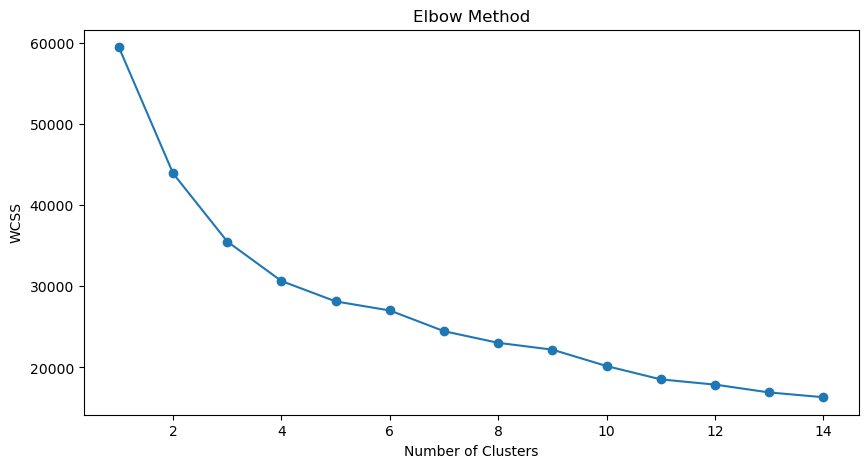

In [60]:
plt.figure(figsize=(10,5))
plt.plot(range(1,15),wcss,'-o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [63]:
km=KMeans(n_clusters=4,random_state=42)
kmeans_clustering=km.fit(scaled_data)
kmeans_clustering

KMeans(n_clusters=4, random_state=42)

In [65]:
kmeans_label=kmeans_clustering.labels_
kmeans_labels=pd.Series(kmeans_label, name='KMEANS LABELS')
kmeans_labels

0       0
1       3
2       3
3       3
4       3
       ..
2699    0
2700    2
2701    1
2702    0
2703    1
Name: KMEANS LABELS, Length: 2704, dtype: int32

In [67]:
data['Cluster_KMeans'] = kmeans.fit_predict(scaled_data)

In [69]:
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster_KMeans
0,0.020000,48.966901,87931.000000,Algeria,39.999418,2.699800e+04,5.479006e+10,0.03500,60.000000,302.068503,...,67.000000,0.000000,0.342000,0.619000,0.039000,31719449,0.599,1.020000e+08,1.930000e+08,0
1,0.050000,48.966901,9542.000000,Angola,39.999418,7.499000e+03,9.129595e+09,0.03400,22.000000,302.068503,...,44.000000,0.000000,0.476000,0.499000,0.025000,13924930,0.324,3.400000e+07,1.460000e+08,3
2,0.043000,48.966901,1617.000000,Benin,39.999418,1.983000e+03,2.359122e+09,0.04300,15.000000,302.068503,...,53.000000,0.000000,0.454000,0.517000,0.029000,6949366,0.383,7.700000e+07,5.000000e+07,3
3,0.027000,48.966901,4276.000000,Botswana,39.999418,1.836000e+03,5.788312e+09,0.04700,152.000000,302.068503,...,49.000000,0.100000,0.383000,0.587000,0.029000,1755375,0.532,2.270000e+08,2.090000e+08,8
4,0.046000,48.966901,1041.000000,Burkina Faso,39.999418,7.723684e+04,2.610959e+09,0.05100,12.000000,302.068503,...,49.000000,0.000000,0.468000,0.505000,0.028000,11607944,0.178,2.300000e+07,3.000000e+07,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.022715,48.966901,142307.107765,Turks and Caicos Islands,39.999418,7.723684e+04,2.638540e+11,0.06417,801.397077,302.068503,...,66.461838,0.578124,0.303051,0.623481,0.073465,32427,0.911,4.939320e+09,4.729435e+09,7
2700,0.013000,46.400000,142307.107765,United States,5.000000,2.132446e+06,1.624460e+13,0.17900,8895.000000,175.000000,...,76.000000,1.000000,0.196000,0.667000,0.136000,313873685,0.811,2.000920e+11,1.265730e+11,2
2701,0.015000,41.900000,142307.107765,Uruguay,7.000000,7.723684e+04,5.000435e+10,0.08900,1308.000000,310.000000,...,74.000000,1.500000,0.220000,0.639000,0.140000,3395253,0.948,2.222000e+09,1.028000e+09,13
2702,0.020000,61.900000,142307.107765,"Venezuela, RB",144.000000,7.723684e+04,3.812862e+11,0.04600,593.000000,792.000000,...,72.000000,1.000000,0.288000,0.652000,0.060000,29954782,0.889,9.040000e+08,3.202000e+09,7


In [71]:
kmeans_sht=silhouette_score(scaled_data,kmeans_labels)
print(f'Silhouette Score (K-Means): {kmeans_sht}')

Silhouette Score (K-Means): 0.251956560114887


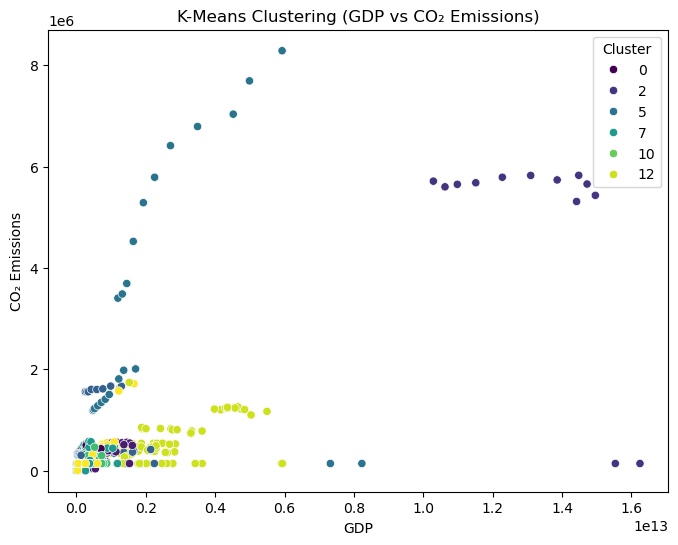

In [73]:
#Visualization for k means clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['GDP'], y=data['CO2 Emissions'], hue=data['Cluster_KMeans'], palette='viridis')
plt.title('K-Means Clustering (GDP vs CO₂ Emissions)')
plt.xlabel('GDP')
plt.ylabel('CO₂ Emissions')
plt.legend(title='Cluster')
plt.show()

### Hierarchical Clustering

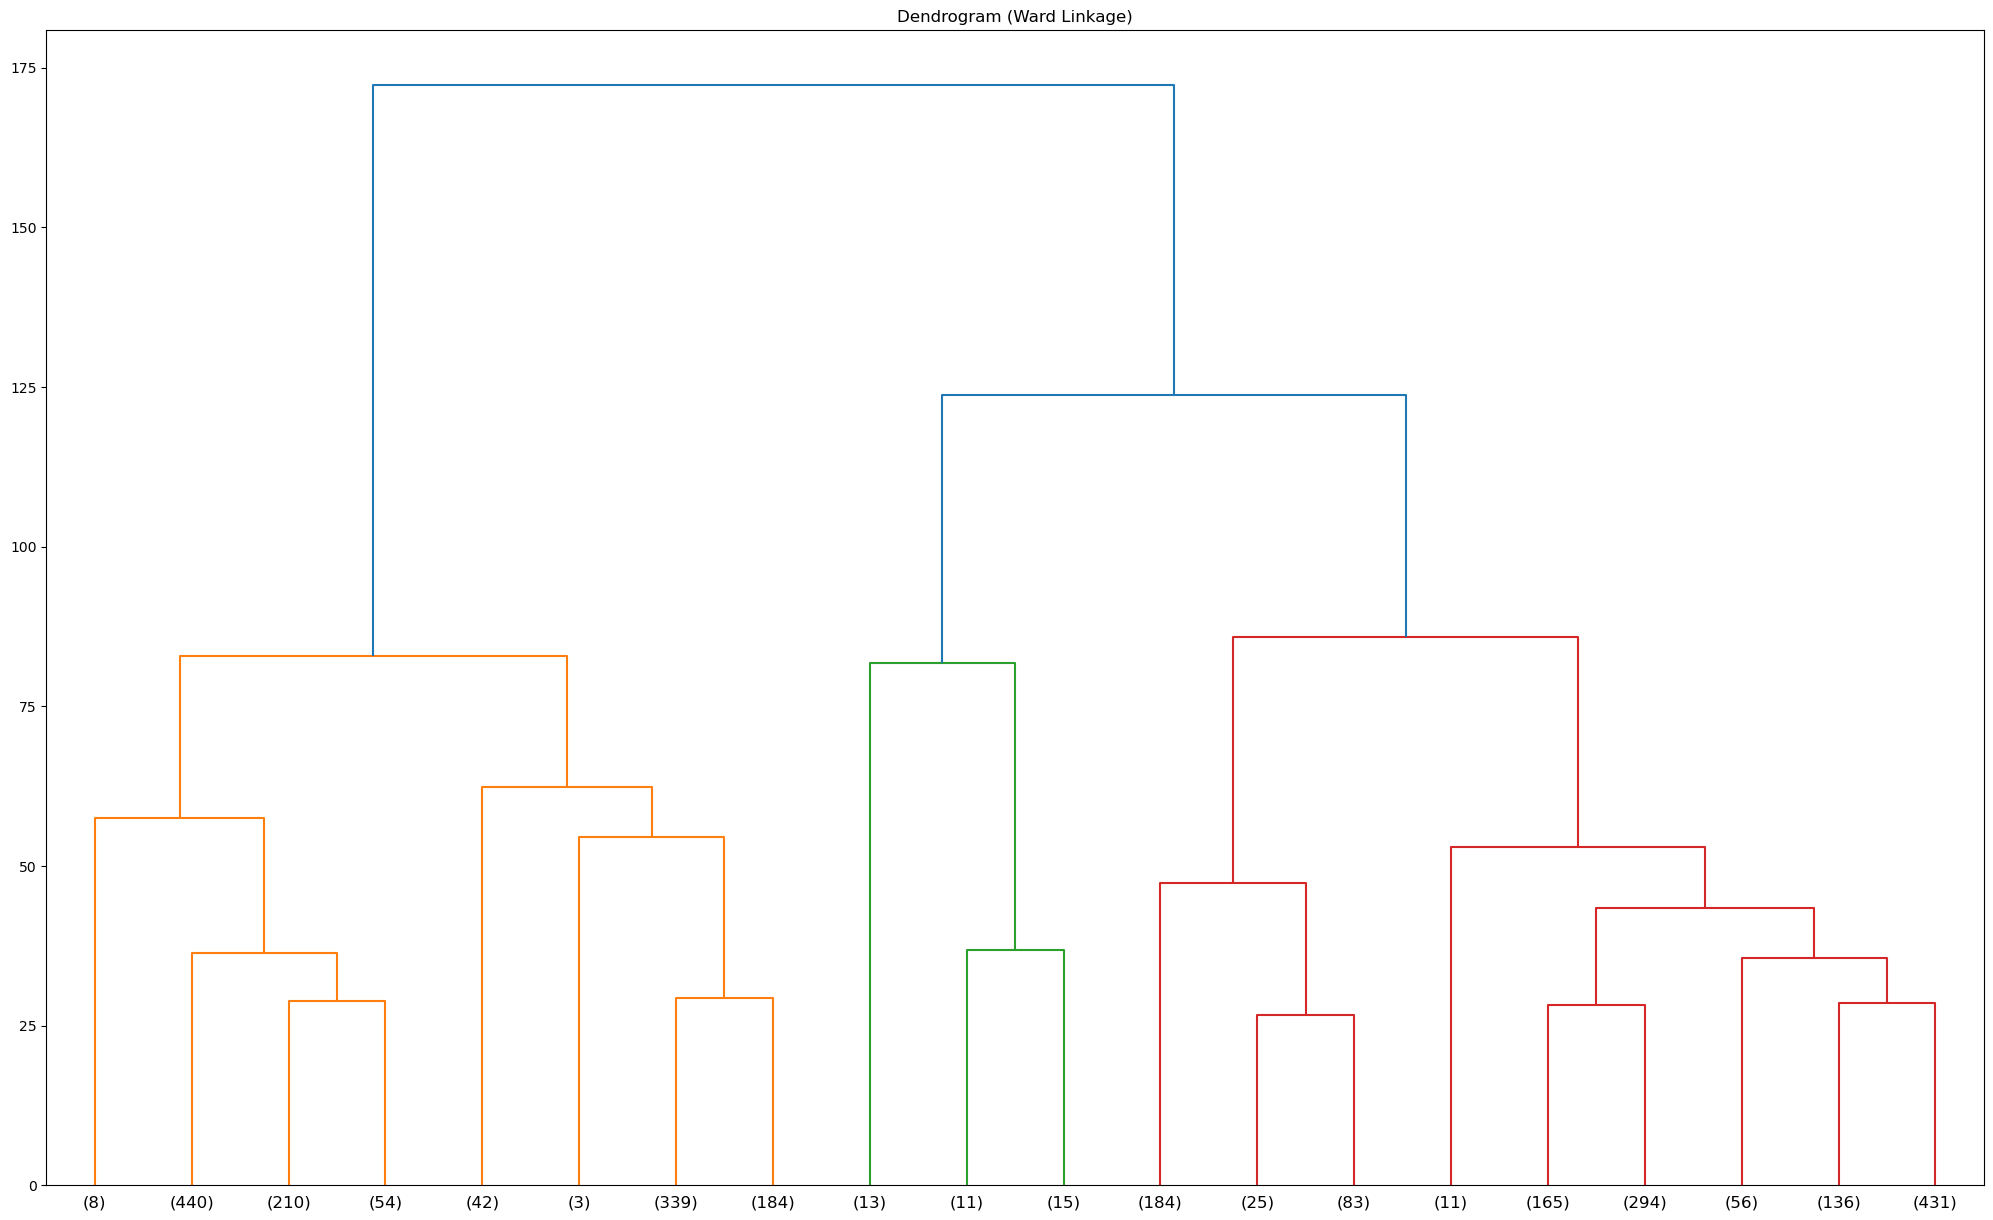

In [76]:
plt.figure(figsize=(25, 15))
sch.dendrogram(sch.linkage(scaled_data, method="ward"),truncate_mode='lastp',p=20)
plt.title("Dendrogram (Ward Linkage)")
plt.show()

In [78]:
hierarchical_clusters=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='complete')
hii=hierarchical_clusters.fit(scaled_data)
hii

AgglomerativeClustering(linkage='complete', n_clusters=5)

In [80]:
labels=hierarchical_clusters.labels_
labels

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [82]:
data['Cluster_Hierarchical'] = hierarchical_clusters.fit_predict(scaled_data)
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster_KMeans,Cluster_Hierarchical
0,0.020000,48.966901,87931.000000,Algeria,39.999418,2.699800e+04,5.479006e+10,0.03500,60.000000,302.068503,...,0.000000,0.342000,0.619000,0.039000,31719449,0.599,1.020000e+08,1.930000e+08,0,0
1,0.050000,48.966901,9542.000000,Angola,39.999418,7.499000e+03,9.129595e+09,0.03400,22.000000,302.068503,...,0.000000,0.476000,0.499000,0.025000,13924930,0.324,3.400000e+07,1.460000e+08,3,0
2,0.043000,48.966901,1617.000000,Benin,39.999418,1.983000e+03,2.359122e+09,0.04300,15.000000,302.068503,...,0.000000,0.454000,0.517000,0.029000,6949366,0.383,7.700000e+07,5.000000e+07,3,0
3,0.027000,48.966901,4276.000000,Botswana,39.999418,1.836000e+03,5.788312e+09,0.04700,152.000000,302.068503,...,0.100000,0.383000,0.587000,0.029000,1755375,0.532,2.270000e+08,2.090000e+08,8,0
4,0.046000,48.966901,1041.000000,Burkina Faso,39.999418,7.723684e+04,2.610959e+09,0.05100,12.000000,302.068503,...,0.000000,0.468000,0.505000,0.028000,11607944,0.178,2.300000e+07,3.000000e+07,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.022715,48.966901,142307.107765,Turks and Caicos Islands,39.999418,7.723684e+04,2.638540e+11,0.06417,801.397077,302.068503,...,0.578124,0.303051,0.623481,0.073465,32427,0.911,4.939320e+09,4.729435e+09,7,0
2700,0.013000,46.400000,142307.107765,United States,5.000000,2.132446e+06,1.624460e+13,0.17900,8895.000000,175.000000,...,1.000000,0.196000,0.667000,0.136000,313873685,0.811,2.000920e+11,1.265730e+11,2,3
2701,0.015000,41.900000,142307.107765,Uruguay,7.000000,7.723684e+04,5.000435e+10,0.08900,1308.000000,310.000000,...,1.500000,0.220000,0.639000,0.140000,3395253,0.948,2.222000e+09,1.028000e+09,13,0
2702,0.020000,61.900000,142307.107765,"Venezuela, RB",144.000000,7.723684e+04,3.812862e+11,0.04600,593.000000,792.000000,...,1.000000,0.288000,0.652000,0.060000,29954782,0.889,9.040000e+08,3.202000e+09,7,0


In [84]:
hierarachy_sht=silhouette_score(scaled_data,labels)
print(f'Silhouette Score (Hierarchical): {hierarachy_sht}')

Silhouette Score (Hierarchical): 0.5840317850869033


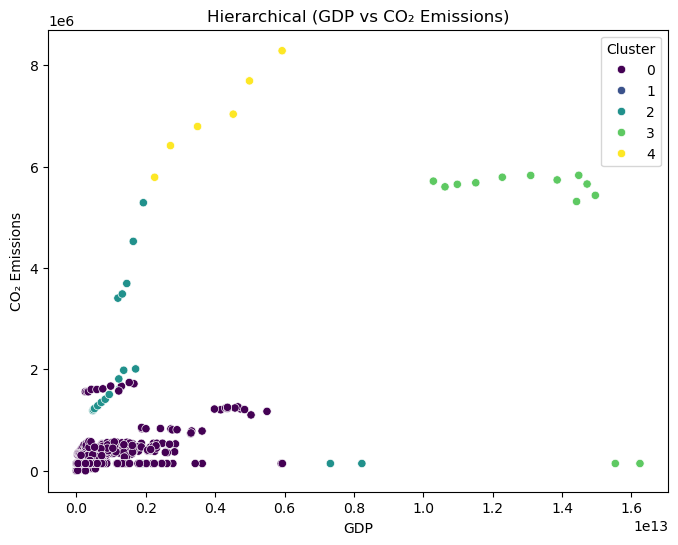

In [86]:
#Visualization for Hierarchical clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['GDP'], y=data['CO2 Emissions'], hue=data['Cluster_Hierarchical'], palette='viridis')
plt.title('Hierarchical (GDP vs CO₂ Emissions)')
plt.xlabel('GDP')
plt.ylabel('CO₂ Emissions')
plt.legend(title='Cluster')
plt.show()

### DBSCAN

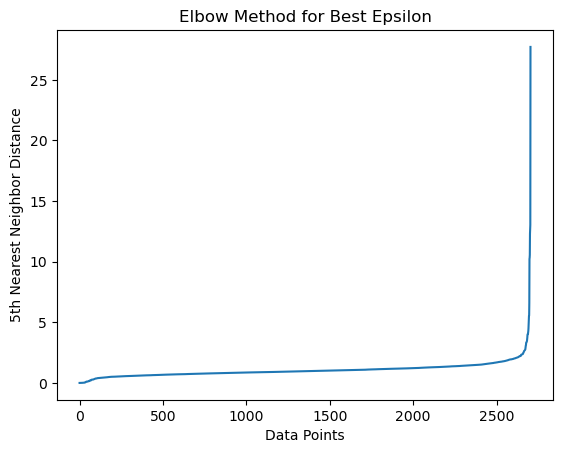

In [89]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("Elbow Method for Best Epsilon")
plt.show()

In [90]:
dbscan = DBSCAN(eps=3, min_samples=5)
dbs=dbscan.fit(scaled_data)
dbs

DBSCAN(eps=3)

In [93]:
dbs_labels=dbs.labels_
dbs_labels

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [95]:
data['Cluster_DBSCAN']=dbs.fit_predict(scaled_data)
data

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster_KMeans,Cluster_Hierarchical,Cluster_DBSCAN
0,0.020000,48.966901,87931.000000,Algeria,39.999418,2.699800e+04,5.479006e+10,0.03500,60.000000,302.068503,...,0.342000,0.619000,0.039000,31719449,0.599,1.020000e+08,1.930000e+08,0,0,0
1,0.050000,48.966901,9542.000000,Angola,39.999418,7.499000e+03,9.129595e+09,0.03400,22.000000,302.068503,...,0.476000,0.499000,0.025000,13924930,0.324,3.400000e+07,1.460000e+08,3,0,0
2,0.043000,48.966901,1617.000000,Benin,39.999418,1.983000e+03,2.359122e+09,0.04300,15.000000,302.068503,...,0.454000,0.517000,0.029000,6949366,0.383,7.700000e+07,5.000000e+07,3,0,0
3,0.027000,48.966901,4276.000000,Botswana,39.999418,1.836000e+03,5.788312e+09,0.04700,152.000000,302.068503,...,0.383000,0.587000,0.029000,1755375,0.532,2.270000e+08,2.090000e+08,8,0,0
4,0.046000,48.966901,1041.000000,Burkina Faso,39.999418,7.723684e+04,2.610959e+09,0.05100,12.000000,302.068503,...,0.468000,0.505000,0.028000,11607944,0.178,2.300000e+07,3.000000e+07,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,0.022715,48.966901,142307.107765,Turks and Caicos Islands,39.999418,7.723684e+04,2.638540e+11,0.06417,801.397077,302.068503,...,0.303051,0.623481,0.073465,32427,0.911,4.939320e+09,4.729435e+09,7,0,0
2700,0.013000,46.400000,142307.107765,United States,5.000000,2.132446e+06,1.624460e+13,0.17900,8895.000000,175.000000,...,0.196000,0.667000,0.136000,313873685,0.811,2.000920e+11,1.265730e+11,2,3,-1
2701,0.015000,41.900000,142307.107765,Uruguay,7.000000,7.723684e+04,5.000435e+10,0.08900,1308.000000,310.000000,...,0.220000,0.639000,0.140000,3395253,0.948,2.222000e+09,1.028000e+09,13,0,0
2702,0.020000,61.900000,142307.107765,"Venezuela, RB",144.000000,7.723684e+04,3.812862e+11,0.04600,593.000000,792.000000,...,0.288000,0.652000,0.060000,29954782,0.889,9.040000e+08,3.202000e+09,7,0,0


In [97]:
dbscan_sht=silhouette_score(scaled_data,dbs_labels)
print(f'Silhouette Score (DBSCAN): {dbscan_sht}')

Silhouette Score (DBSCAN): 0.1899381168103011


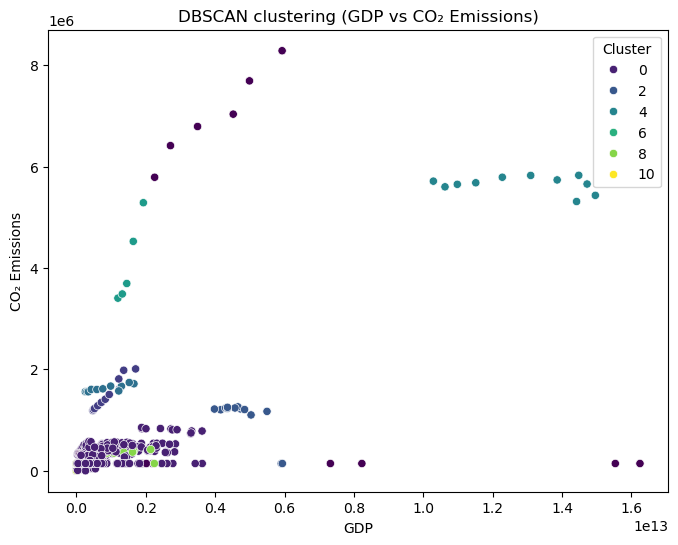

In [99]:
#Visualization for DBSCAN clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['GDP'], y=data['CO2 Emissions'], hue=data['Cluster_DBSCAN'], palette='viridis')
plt.title('DBSCAN clustering (GDP vs CO₂ Emissions)')
plt.xlabel('GDP')
plt.ylabel('CO₂ Emissions')
plt.legend(title='Cluster')
plt.show()

### Dumbing The Model

In [101]:
import pickle

In [105]:
pickle.dump(hierarchical_clusters,open('HCM.pkl','wb'))